<a href="https://colab.research.google.com/github/samatta002/DevSession1/blob/main/Hadoop_and_Hive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![alt text](https://github.com/Praxis-QR/RDWH/raw/main/images/YantraJaalBanner.png)<br>


<hr>

[Prithwis Mukerjee](http://www.linkedin.com/in/prithwis)<br>

In [ ]:
from datetime import datetime
import pytz
print('Tested',datetime.now(pytz.timezone('Asia/Calcutta')))

Tested 2024-03-12 13:35:49.260269+05:30


#Hive with Hadoop
This notebook has all the codes / commands required to install Hadoop and Hive <br>



##Acknowledgements
Hadoop Installation from [Anjaly Sam's Github Repository](https://github.com/anjalysam/Hadoop) <br>
Hive Installation from [PhoenixNAP](https://phoenixnap.com/kb/install-hive-on-ubuntu) website

#1 Hadoop
Hadoop is a pre-requisite for Hive <br>


## 1.1 Download, Install Hadoop

In [1]:
# The default JVM available at /usr/lib/jvm/java-11-openjdk-amd64/  works for Hadoop
# But gives errors with Hive https://stackoverflow.com/questions/54037773/hive-exception-class-jdk-internal-loader-classloadersappclassloader-cannot
# Hence this JVM needs to be installed
!apt-get update > /dev/null
!apt-get install openjdk-8-jdk-headless -qq > /dev/null


# If there is an error in this cell, it is very likely that the version of hadoop has changed
# Download the latest version of Hadoop and change the version numbers accordingly
#wget -q https://downloads.apache.org/hadoop/common/hadoop-3.3.0/hadoop-3.3.0.tar.gz
#!wget -q https://downloads.apache.org/hadoop/common/hadoop-3.3.2/hadoop-3.3.2.tar.gz
#!wget  https://downloads.apache.org/hadoop/common/hadoop-3.3.2/hadoop-3.3.2.tar.gz
!wget -q https://downloads.apache.org/hadoop/common/hadoop-3.3.5/hadoop-3.3.5.tar.gz
# Unzip it
# the tar command with the -x flag to extract, -z to uncompress, -v for verbose output, and -f to specify that we’re extracting from a file
#!tar -xzf hadoop-3.3.2.tar.gz
!tar -xzf hadoop-3.3.5.tar.gz
#copy  hadoop file to user/local
#!mv  hadoop-3.3.2/ /usr/local/
!mv  hadoop-3.3.5/ /usr/local/

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


## 1.2 Set Environment Variables


In [2]:
#To set java path, go to /usr/local/hadoop-3.3.0/etc/hadoop/hadoop-env.sh then
#. . . export JAVA_HOME=/usr/lib/jvm/java-11-openjdk-amd64/ . . .
#we have used a simpler alternative route using os.environ - it works

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"   # default is changed
#os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64/"
# make sure that the version number is as downloaded
#os.environ["HADOOP_HOME"] = "/usr/local/hadoop-3.3.0/"
#os.environ["HADOOP_HOME"] = "/usr/local/hadoop-3.3.2/"
os.environ["HADOOP_HOME"] = "/usr/local/hadoop-3.3.5/"

In [3]:
# Add Hadoop BIN to PATH
# Get the current_path from output of previous command
#current_path = '/usr/local/nvidia/bin:/usr/local/cuda/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/tools/node/bin:/tools/google-cloud-sdk/bin:/opt/bin'
#current_path = '/usr/local/nvidia/bin:/usr/local/cuda/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/tools/node/bin:/tools/google-cloud-sdk/bin:/opt/bin'
#new_path = current_path+':/usr/local/hadoop-3.3.2/bin/'
#os.environ["PATH"] = new_path
#!echo $PATH

current_path = os.getenv('PATH')
#new_path = current_path+':/usr/local/hadoop-3.3.0/bin/'
#new_path = current_path+':/usr/local/hadoop-3.3.2/bin/'
new_path = current_path+':/usr/local/hadoop-3.3.5/bin/'
os.environ["PATH"] = new_path
!echo $PATH

/opt/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/tools/node/bin:/tools/google-cloud-sdk/bin:/usr/local/hadoop-3.3.5/bin/


## 1.3 Test Hadoop Installation

In [4]:
#Running Hadoop - Test RUN, not doing anything at all
#!/usr/local/hadoop-3.3.0/bin/hadoop
# UNCOMMENT the following line if you want to make sure that Hadoop is alive!
#!hadoop

In [5]:
# Testing Hadoop with PI generating sample program, should calculate value of pi = 3.14157500000000000000
# pi example
#Uncomment the following line if  you want to test Hadoop with pi example
#!hadoop jar /usr/local/hadoop-3.3.0/share/hadoop/mapreduce/hadoop-mapreduce-examples-3.3.0.jar pi 16 100000

#2 Hive

## 2.1 Download, Install HIVE

In [22]:
# Download and Unzip the correct version and unzip
#!wget https://downloads.apache.org/hive/hive-3.1.2/apache-hive-3.1.2-bin.tar.gz
!wget -q https://downloads.apache.org/hive/hive-3.1.3/apache-hive-3.1.3-bin.tar.gz

#!tar xzf apache-hive-3.1.2-bin.tar.gz
!tar xzf apache-hive-3.1.3-bin.tar.gz

tar (child): apache-hive-3.1.3-bin.tar.gz: Cannot open: No such file or directory
tar (child): Error is not recoverable: exiting now
tar: Child returned status 2
tar: Error is not recoverable: exiting now


## 2.2 Set Environment *Variables*

In [7]:
# Make sure that the version number is correct and is as downloaded
#os.environ["HIVE_HOME"] = "/content/apache-hive-3.1.2-bin"
os.environ["HIVE_HOME"] = "/content/apache-hive-3.1.3-bin"
!echo $HIVE_HOME

/content/apache-hive-3.1.3-bin


In [8]:
# current_path is set from output of previous command
#current_path = '/usr/local/nvidia/bin:/usr/local/cuda/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/tools/node/bin:/tools/google-cloud-sdk/bin:/opt/bin:/usr/local/hadoop-3.3.0/bin/'
#current_path = '/opt/bin:/usr/local/nvidia/bin:/usr/local/cuda/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/tools/node/bin:/tools/google-cloud-sdk/bin:/usr/local/hadoop-3.3.2/bin/'
#new_path = current_path+':/content/apache-hive-3.1.2-bin/bin'
#os.environ["PATH"] = new_path
!echo $PATH


current_path = os.getenv('PATH')
#new_path = current_path+':/usr/local/hadoop-3.3.0/bin/'
#new_path = current_path+':/content/apache-hive-3.1.2-bin/bin'
new_path = current_path+':/content/apache-hive-3.1.3-bin/bin'
os.environ["PATH"] = new_path
!echo $PATH

/opt/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/tools/node/bin:/tools/google-cloud-sdk/bin:/usr/local/hadoop-3.3.5/bin/
/opt/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/tools/node/bin:/tools/google-cloud-sdk/bin:/usr/local/hadoop-3.3.5/bin/:/content/apache-hive-3.1.3-bin/bin


In [9]:
!echo $JAVA_HOME
!echo $HADOOP_HOME
!echo $HIVE_HOME

/usr/lib/jvm/java-8-openjdk-amd64
/usr/local/hadoop-3.3.5/
/content/apache-hive-3.1.3-bin


## 2.3 Set up HDFS Directories

In [10]:
!hdfs dfs -mkdir /tmp
!hdfs dfs -chmod g+w /tmp
#!hdfs dfs -ls /
!hdfs dfs -mkdir -p /content/warehouse
!hdfs dfs -chmod g+w /content/warehouse
#!hdfs dfs -ls /content/

mkdir: `/tmp': File exists


## 2.4 Initialise HIVE - note and fix errors

In [11]:
# TYPE this command, do not copy and paste. Non printing characters cause havoc
# There will be two errors, that we will fix
# UNCOMMENT the following line if you WISH TO SEE the errors
#!schematool -initSchema -dbType derby


### 2.4.1 Fix One Warning, One Error
SLF4J is duplicate, need to locate them and remove one <br>
Guava jar version is low

In [12]:
# locate multiple instances of slf4j ...
!ls $HADOOP_HOME/share/hadoop/common/lib/*slf4j*
!ls $HIVE_HOME/lib/*slf4j*

/usr/local/hadoop-3.3.5//share/hadoop/common/lib/jul-to-slf4j-1.7.36.jar
/usr/local/hadoop-3.3.5//share/hadoop/common/lib/slf4j-api-1.7.36.jar
/usr/local/hadoop-3.3.5//share/hadoop/common/lib/slf4j-reload4j-1.7.36.jar
ls: cannot access '/content/apache-hive-3.1.3-bin/lib/*slf4j*': No such file or directory


In [13]:
# removed the logging jar from Hive, retaining the Hadoop jar
#!mv /content/apache-hive-3.1.2-bin/lib/log4j-slf4j-impl-2.10.0.jar ./
!mv /content/apache-hive-3.1.3-bin/lib/log4j-slf4j-impl-2.17.1.jar ./

mv: cannot stat '/content/apache-hive-3.1.3-bin/lib/log4j-slf4j-impl-2.17.1.jar': No such file or directory


In [14]:
# guava jar needs to above v 20
# https://stackoverflow.com/questions/45247193/nosuchmethoderror-com-google-common-base-preconditions-checkargumentzljava-lan
!ls $HIVE_HOME/lib/gu*

ls: cannot access '/content/apache-hive-3.1.3-bin/lib/gu*': No such file or directory


In [15]:
# the one available with Hadoop is better, v 27
!ls $HADOOP_HOME/share/hadoop/hdfs/lib/gu*

/usr/local/hadoop-3.3.5//share/hadoop/hdfs/lib/guava-27.0-jre.jar


In [16]:
# Remove the Hive Guava and replace with Hadoop Guava
!mv $HIVE_HOME/lib/guava-19.0.jar ./

!cp $HADOOP_HOME/share/hadoop/hdfs/lib/guava-27.0-jre.jar $HIVE_HOME/lib/

mv: cannot stat '/content/apache-hive-3.1.3-bin/lib/guava-19.0.jar': No such file or directory
cp: cannot create regular file '/content/apache-hive-3.1.3-bin/lib/': No such file or directory


##2.5 Initialize HIVE

In [17]:
!pip -q install colab-xterm
%load_ext colabxterm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.6/115.6 kB 1.6 MB/s eta 0:00:00


In [ ]:
%xterm

Launching Xterm...

<IPython.core.display.Javascript object>

In [ ]:
#Type this command, dont copy-paste
# Non printing characters inside the command will give totally illogical errors
!schematool -initSchema -dbType derby

Metastore connection URL:	 jdbc:derby:;databaseName=metastore_db;create=true
Metastore Connection Driver :	 org.apache.derby.jdbc.EmbeddedDriver
Metastore connection User:	 APP
Starting metastore schema initialization to 3.1.0
Initialization script hive-schema-3.1.0.derby.sql

 
 
 
 
 
 
 
 
 

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 

 
 
 
 
 
 
 
 

 

 
 
 

 
 
 


 
 
 

 
 
 


 
 
 
 
 
 
 


 
 
 

 
 
 

 
 

 
 
 
 
 

 
 
 
 
 
 
 
 
 
 
 
 

 
 
 
 

 

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 

 
 
 

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 

 
 


 



 


 
 
 
 
 
 
 
 
 

 
 
 
 
 
 

 


Initialization script completed
schemaTool completed


In [19]:
from google.colab import files
uploaded = files.upload()


Saving ai_student_impact_dataset (1).csv to ai_student_impact_dataset (1).csv


In [20]:
!ls

'ai_student_impact_dataset (1).csv'   sample_data
 hadoop-3.3.5.tar.gz		      warehouse


In [21]:
!hive --version
!hadoop version

/bin/bash: line 1: hive: command not found
Hadoop 3.3.5
Source code repository https://github.com/apache/hadoop.git -r 706d88266abcee09ed78fbaa0ad5f74d818ab0e9
Compiled by stevel on 2023-03-15T15:56Z
Compiled with protoc 3.7.1
From source with checksum 6bbd9afcf4838a0eb12a5f189e9bd7
This command was run using /usr/local/hadoop-3.3.5/share/hadoop/common/hadoop-common-3.3.5.jar


In [23]:
# Download Hive 3.1.3 (compatible with Hadoop 3.x)
!wget https://archive.apache.org/dist/hive/hive-3.1.3/apache-hive-3.1.3-bin.tar.gz
!tar -xzf apache-hive-3.1.3-bin.tar.gz
!mv apache-hive-3.1.3-bin /usr/local/hive

--2026-06-11 22:34:01--  https://archive.apache.org/dist/hive/hive-3.1.3/apache-hive-3.1.3-bin.tar.gz
Resolving archive.apache.org (archive.apache.org)... 65.108.204.189, 2a01:4f9:1a:a084::2
Connecting to archive.apache.org (archive.apache.org)|65.108.204.189|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 326940667 (312M) [application/x-gzip]
Saving to: ‘apache-hive-3.1.3-bin.tar.gz’

apache-hive-3.1.3-b 100%[===================>] 311.79M  15.8MB/s    in 20s     

2026-06-11 22:34:22 (15.8 MB/s) - ‘apache-hive-3.1.3-bin.tar.gz’ saved [326940667/326940667]



In [24]:
import os
os.environ['HIVE_HOME'] = '/usr/local/hive'
os.environ['PATH'] += ':/usr/local/hive/bin'
# Also add to bashrc for persistence
!echo 'export HIVE_HOME=/usr/local/hive' >> ~/.bashrc
!echo 'export PATH=$PATH:$HIVE_HOME/bin' >> ~/.bashrc

In [25]:
!source ~/.bashrc

In [29]:
%%writefile /usr/local/hive/conf/hive-site.xml
<?xml version="1.0" encoding="UTF-8" standalone="no"?>
<?xml-stylesheet type="text/xsl" href="configuration.xsl"?>
<configuration>
  <property>
    <name>hive.metastore.warehouse.dir</name>
    <value>/user/hive/warehouse</value>
  </property>
  <property>
    <name>javax.jdo.option.ConnectionURL</name>
    <value>jdbc:derby:;databaseName=/usr/local/hive/metastore_db;create=true</value>
  </property>
  <property>
    <name>javax.jdo.option.ConnectionDriverName</name>
    <value>org.apache.derby.jdbc.EmbeddedDriver</value>
  </property>
  <property>
    <name>hive.metastore.schema.verification</name>
    <value>false</value>
  </property>
  <property>
    <name>datanucleus.schema.autoCreateAll</name>
    <value>true</value>
  </property>
</configuration>

Overwriting /usr/local/hive/conf/hive-site.xml


In [30]:
!ls -l /usr/local/hive/conf/
!head -5 /usr/local/hive/conf/hive-site.xml

total 336
-rw-r--r-- 1 root staff   1596 Oct 24  2019 beeline-log4j2.properties.template
-rw-r--r-- 1 root staff 300727 Apr  3  2022 hive-default.xml.template
-rw-r--r-- 1 root staff   2365 Oct 24  2019 hive-env.sh.template
-rw-r--r-- 1 root staff   2274 Oct 24  2019 hive-exec-log4j2.properties.template
-rw-r--r-- 1 root staff   3086 Sep  4  2020 hive-log4j2.properties.template
-rw-r--r-- 1 root root     764 Jun 11 22:43 hive-site.xml
-rw-r--r-- 1 root staff   2060 Oct 24  2019 ivysettings.xml
-rw-r--r-- 1 root staff   3558 Sep  4  2020 llap-cli-log4j2.properties.template
-rw-r--r-- 1 root staff   6937 Mar 28  2022 llap-daemon-log4j2.properties.template
-rw-r--r-- 1 root staff   2662 Oct 24  2019 parquet-logging.properties
<?xml version="1.0" encoding="UTF-8" standalone="no"?>
<?xml-stylesheet type="text/xsl" href="configuration.xsl"?>
<configuration>
  <property>
    <name>hive.metastore.warehouse.dir</name>


In [31]:
# Remove Hive's Guava (older) and copy Hadoop's newer Guava
!rm /usr/local/hive/lib/guava-*.jar
!cp /usr/local/hadoop-3.3.5/share/hadoop/common/lib/guava-27.0-jre.jar /usr/local/hive/lib/

# Remove conflicting log4j-slf4j
!rm /usr/local/hive/lib/log4j-slf4j-impl-2.10.0.jar

rm: cannot remove '/usr/local/hive/lib/log4j-slf4j-impl-2.10.0.jar': No such file or directory


In [32]:
!ls /usr/local/hive/lib/ | grep -i "log4j-slf4j"

log4j-slf4j-impl-2.17.1.jar


In [33]:
!rm /usr/local/hive/lib/log4j-slf4j-impl-2.17.1.jar   # change if version differs

In [34]:
!rm /usr/local/hive/lib/guava-*.jar
!cp /usr/local/hadoop-3.3.5/share/hadoop/common/lib/guava-27.0-jre.jar /usr/local/hive/lib/

In [35]:
# Make sure Hive can find Hadoop jars
!export HADOOP_HOME=/usr/local/hadoop-3.3.5
!export HADOOP_CLASSPATH=$(hadoop classpath)

# Initialize Derby metastore
!schematool -dbType derby -initSchema

Metastore connection URL:	 jdbc:derby:;databaseName=/usr/local/hive/metastore_db;create=true
Metastore Connection Driver :	 org.apache.derby.jdbc.EmbeddedDriver
Metastore connection User:	 APP
Starting metastore schema initialization to 3.1.0
Initialization script hive-schema-3.1.0.derby.sql

 
 
 
 
 
 
 
 
 

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 

 
 
 
 
 
 
 
 

 

 
 
 

 
 
 


 
 
 

 
 
 


 
 
 
 
 
 
 


 
 
 

 
 
 

 
 

 
 
 
 
 

 
 
 
 
 
 
 
 
 
 
 
 

 
 
 
 
 
 

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 

 
 
 
 
 
 
 

 
 
 

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 

 
 


 



 


 
 
 
 
 
 
 
 
 

 
 
 
 
 
 

 


Initialization script completed
schemaTool completed


In [36]:
!hive --version

Hive 3.1.3
Git git://MacBook-Pro.fios-router.home/Users/ngangam/commit/hive -r 4df4d75bf1e16fe0af75aad0b4179c34c07fc975
Compiled by ngangam on Sun Apr 3 16:58:16 EDT 2022
From source with checksum 5da234766db5dfbe3e92926c9bbab2af


In [37]:
!hive -e "show databases;"

Hive Session ID = f55f7fde-b275-4bb3-be10-81b501727702

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = 2a04d85f-026c-497b-990f-9d2c49095e3c
OK
default
Time taken: 2.297 seconds, Fetched: 1 row(s)


In [38]:
!mv "ai_student_impact_dataset (1).csv" student_ai.csv

In [39]:
%%sql
CREATE EXTERNAL TABLE student_ai (
    Student_ID INT,
    Year_of_Study STRING,
    Pre_Semester_GPA DOUBLE,
    Weekly_GenAI_Hours DOUBLE,
    Primary_Use_Case STRING,
    Prompt_Engineering_Skill STRING,
    Tool_Diversity INT,
    Paid_Subscription BOOLEAN,
    Traditional_Study_Hours DOUBLE,
    Perceived_AI_Dependency INT,
    Institutional_Policy STRING,
    Anxiety_Level_During_Exams INT,
    Post_Semester_GPA DOUBLE,
    Skill_Retention_Score DOUBLE,
    Burnout_Risk_Level STRING
)
PARTITIONED BY (Major_Category STRING)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
WITH SERDEPROPERTIES ("separatorChar" = ",", "quoteChar" = "\"")
STORED AS TEXTFILE
LOCATION '/user/hive/warehouse/student_ai';

UsageError: Cell magic `%%sql` not found.


In [40]:
!hive --version

Hive 3.1.3
Git git://MacBook-Pro.fios-router.home/Users/ngangam/commit/hive -r 4df4d75bf1e16fe0af75aad0b4179c34c07fc975
Compiled by ngangam on Sun Apr 3 16:58:16 EDT 2022
From source with checksum 5da234766db5dfbe3e92926c9bbab2af


In [43]:
create_table_query = """
CREATE EXTERNAL TABLE student_ai (
    Student_ID INT,
    Year_of_Study STRING,
    Pre_Semester_GPA DOUBLE,
    Weekly_GenAI_Hours DOUBLE,
    Primary_Use_Case STRING,
    Prompt_Engineering_Skill STRING,
    Tool_Diversity INT,
    Paid_Subscription BOOLEAN,
    Traditional_Study_Hours DOUBLE,
    Perceived_AI_Dependency INT,
    Institutional_Policy STRING,
    Anxiety_Level_During_Exams INT,
    Post_Semester_GPA DOUBLE,
    Skill_Retention_Score DOUBLE,
    Burnout_Risk_Level STRING
)
PARTITIONED BY (Major_Category STRING)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
WITH SERDEPROPERTIES (
   'separatorChar' = ',',
   'quoteChar' = '\\"'
)
STORED AS TEXTFILE
LOCATION '/user/hive/warehouse/student_ai'
"""

!hive -e "$create_table_query"

Hive Session ID = 914e35b6-787b-4ab8-987c-12abe268022a

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = 62a68ebd-9641-46d9-82c3-800cdd7ac306
OK
Time taken: 2.693 seconds


In [44]:
staging_query = """
CREATE TABLE student_ai_staging (
    Student_ID INT,
    Year_of_Study STRING,
    Pre_Semester_GPA DOUBLE,
    Weekly_GenAI_Hours DOUBLE,
    Primary_Use_Case STRING,
    Prompt_Engineering_Skill STRING,
    Tool_Diversity INT,
    Paid_Subscription BOOLEAN,
    Traditional_Study_Hours DOUBLE,
    Perceived_AI_Dependency INT,
    Institutional_Policy STRING,
    Anxiety_Level_During_Exams INT,
    Post_Semester_GPA DOUBLE,
    Skill_Retention_Score DOUBLE,
    Burnout_Risk_Level STRING,
    Major_Category STRING
)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
WITH SERDEPROPERTIES (
   'separatorChar' = ',',
   'quoteChar' = '\\"'
)
STORED AS TEXTFILE
"""

!hive -e "$staging_query"

Hive Session ID = b8c369d0-74cf-4b26-8200-163fb69d781c

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = 6a0e7247-9971-4a1d-8224-0e5add744fc7
OK
Time taken: 3.378 seconds


In [45]:
load_query = "LOAD DATA LOCAL INPATH 'student_ai.csv' OVERWRITE INTO TABLE student_ai_staging"
!hive -e "$load_query"

Hive Session ID = c211f1c6-e883-41de-a431-1afec2f465c8

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = b837ce6a-9ff0-4d5c-a346-466d573af965
Loading data to table default.student_ai_staging
OK
Time taken: 3.672 seconds


In [46]:
!hive -e "SELECT COUNT(*) FROM student_ai_staging"

Hive Session ID = 31a7ce29-b489-4b2e-b3bc-71d045435ec4

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = 00e212b9-2b26-42aa-b821-09ce45092d00
Query ID = root_20260611225657_9c2d80f5-b9dd-4369-8719-66a54bfa454c
Total jobs = 1
Launching Job 1 out of 1
Number of reduce tasks determined at compile time: 1
In order to change the average load for a reducer (in bytes):
  set hive.exec.reducers.bytes.per.reducer=<number>
In order to limit the maximum number of reducers:
  set hive.exec.reducers.max=<number>
In order to set a constant number of reducers:
  set mapreduce.job.reduces=<number>
Job running in-process (local Hadoop)
2026-06-11 22:57:07,145 Stage-1 map = 0%,  reduce = 0%
2026-06-11 22:57:14,616 Stage-1 map = 100%,  reduce = 100%
Ended Job = job_local1706801567_0001
MapReduce Jobs Launched: 
Stage-Stage-1:  HDFS Read: 0 HDFS Write: 0 SUCCESS
Total MapReduce CPU Time Spent: 0 msec
OK
5000

In [47]:
insert_query = """
SET hive.exec.dynamic.partition=true;
SET hive.exec.dynamic.partition.mode=nonstrict;
INSERT OVERWRITE TABLE student_ai PARTITION(Major_Category)
SELECT
    Student_ID, Year_of_Study, Pre_Semester_GPA, Weekly_GenAI_Hours,
    Primary_Use_Case, Prompt_Engineering_Skill, Tool_Diversity,
    Paid_Subscription, Traditional_Study_Hours, Perceived_AI_Dependency,
    Institutional_Policy, Anxiety_Level_During_Exams, Post_Semester_GPA,
    Skill_Retention_Score, Burnout_Risk_Level, Major_Category
FROM student_ai_staging
"""

!hive -e "$insert_query"

Hive Session ID = 346b62f6-77f3-4d97-ad11-0e91a427e927

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = 97dbf345-ee6b-48e2-b521-bb8d0a7cbe05
Query ID = root_20260611225815_aab04206-51f6-47cd-9f46-0bde29c410c8
Total jobs = 3
Launching Job 1 out of 3
Number of reduce tasks not specified. Estimated from input data size: 1
In order to change the average load for a reducer (in bytes):
  set hive.exec.reducers.bytes.per.reducer=<number>
In order to limit the maximum number of reducers:
  set hive.exec.reducers.max=<number>
In order to set a constant number of reducers:
  set mapreduce.job.reduces=<number>
Job running in-process (local Hadoop)
2026-06-11 22:58:25,481 Stage-1 map = 0%,  reduce = 0%
2026-06-11 22:58:33,448 Stage-1 map = 100%,  reduce = 100%
Ended Job = job_local220571566_0001
Stage-4 is selected by condition resolver.
Stage-3 is filtered out by condition resolver.
Stage-5 is filt

In [48]:
!hive -e "SHOW PARTITIONS student_ai"

Hive Session ID = 570231df-df72-4ace-a8ca-22a65d543921

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = 5bbf3bbb-a642-4edf-80fa-e563d4ac87b0
OK
major_category=Burnout_Risk_Level
major_category=High
major_category=Low
major_category=Medium
Time taken: 4.96 seconds, Fetched: 4 row(s)


In [49]:
!hive -e "SHOW TABLES;"

Hive Session ID = 0cadd1ae-9f28-4c47-849c-e5bfb153ce5c

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = 830dea6c-a6f9-48b1-ac01-f204c72d6cbe
OK
student_ai
student_ai_staging
Time taken: 2.252 seconds, Fetched: 2 row(s)


In [50]:
!hive -e "DESCRIBE student_ai;"

Hive Session ID = 78564ec1-a63f-43e2-ac5d-b80127218c73

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = d2c1015c-61e5-4dae-803c-e126145f81ac
OK
student_id          	string              	from deserializer   
year_of_study       	string              	from deserializer   
pre_semester_gpa    	string              	from deserializer   
weekly_genai_hours  	string              	from deserializer   
primary_use_case    	string              	from deserializer   
prompt_engineering_skill	string              	from deserializer   
tool_diversity      	string              	from deserializer   
paid_subscription   	string              	from deserializer   
traditional_study_hours	string              	from deserializer   
perceived_ai_dependency	string              	from deserializer   
institutional_policy	string              	from deserializer   
anxiety_level_during_exams	string              	from 

In [52]:
!hive -e "SELECT COUNT(*) FROM student_ai;"

Hive Session ID = a6db8de3-cc6c-4768-83f4-86714062a2ae

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = 5ce7445c-529e-4667-a618-c777c964d190
Query ID = root_20260611230400_524cf24d-82b2-4a96-ac35-02484b0b7f96
Total jobs = 1
Launching Job 1 out of 1
Number of reduce tasks determined at compile time: 1
In order to change the average load for a reducer (in bytes):
  set hive.exec.reducers.bytes.per.reducer=<number>
In order to limit the maximum number of reducers:
  set hive.exec.reducers.max=<number>
In order to set a constant number of reducers:
  set mapreduce.job.reduces=<number>
Job running in-process (local Hadoop)
2026-06-11 23:04:11,346 Stage-1 map = 0%,  reduce = 0%
2026-06-11 23:04:18,104 Stage-1 map = 100%,  reduce = 100%
Ended Job = job_local658752250_0001
MapReduce Jobs Launched: 
Stage-Stage-1:  HDFS Read: 0 HDFS Write: 0 SUCCESS
Total MapReduce CPU Time Spent: 0 msec
OK
50001

In [53]:
!hive -e "SELECT * FROM student_ai LIMIT 10;"

Hive Session ID = 8d326cde-d17f-4354-90ea-a26d62f2c964

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = 543eef59-b5ed-4d51-8be6-fd513969c838
OK
Student_ID	Major_Category	Year_of_Study	Pre_Semester_GPA	Weekly_GenAI_Hours	Primary_Use_Case	Prompt_Engineering_Skill	Tool_Diversity	Paid_Subscription	Traditional_Study_Hours	Perceived_AI_Dependency	Institutional_Policy	Anxiety_Level_During_Exams	Post_Semester_GPA	Skill_Retention_Score	Burnout_Risk_Level
100001	Humanities	Senior	2.418	23.31	Copywriting/Drafting	Beginner	1	True	8.13	5	Allowed_With_Citation	6	2.393	86.44	High
100006	STEM	Junior	3.449	6.5	Debugging/Troubleshooting	Beginner	1	False	14.19	4	Allowed_With_Citation	5	3.666	65.92	High
100010	Business	Sophomore	3.046	19.99	Debugging/Troubleshooting	Intermediate	2	True	12.49	3	Strict_Ban	8	2.978	87.18	High
100011	STEM	Graduate	3.407	5.16	Summarizing_Reading	Advanced	3	False	11.43	5	Allowed_

In [54]:
!hive -e "SELECT Student_ID, Major_Category, Weekly_GenAI_Hours, Post_Semester_GPA FROM student_ai LIMIT 10;"

Hive Session ID = f4225b3d-ca0c-45c7-9131-fd15c8fd805b

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = 248388d7-f46f-4c3f-8881-200abd585766
OK
Student_ID	Burnout_Risk_Level	Pre_Semester_GPA	Anxiety_Level_During_Exams
100001	High	2.418	6
100006	High	3.449	5
100010	High	3.046	8
100011	High	3.407	3
100013	High	3.479	4
100026	High	3.308	2
100028	High	3.302	1
100035	High	3.12	3
100036	High	3.632	5
Time taken: 5.145 seconds, Fetched: 10 row(s)


In [55]:
!hive -e "SELECT COUNT(*) FROM student_ai_staging;"
!hive -e "SELECT * FROM student_ai_staging LIMIT 5;"

Hive Session ID = 68664c69-bdaf-40c4-b1a0-7a880192562b

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = 0cf4d070-5087-4397-95f4-4f1650ec11be
Query ID = root_20260611230653_dd0991d3-289a-4420-a5ae-a818602779b7
Total jobs = 1
Launching Job 1 out of 1
Number of reduce tasks determined at compile time: 1
In order to change the average load for a reducer (in bytes):
  set hive.exec.reducers.bytes.per.reducer=<number>
In order to limit the maximum number of reducers:
  set hive.exec.reducers.max=<number>
In order to set a constant number of reducers:
  set mapreduce.job.reduces=<number>
Job running in-process (local Hadoop)
2026-06-11 23:07:04,383 Stage-1 map = 0%,  reduce = 0%
2026-06-11 23:07:10,760 Stage-1 map = 100%,  reduce = 100%
Ended Job = job_local1460052636_0001
MapReduce Jobs Launched: 
Stage-Stage-1:  HDFS Read: 0 HDFS Write: 0 SUCCESS
Total MapReduce CPU Time Spent: 0 msec
OK
5000

In [56]:
query_gpa = """
SELECT
    CASE
        WHEN Weekly_GenAI_Hours <= 5 THEN 'Low (0-5h)'
        WHEN Weekly_GenAI_Hours <= 20 THEN 'Medium (5-20h)'
        ELSE 'High (>20h)'
    END AS ai_hours_group,
    AVG(Post_Semester_GPA) AS avg_gpa,
    AVG(Skill_Retention_Score) AS avg_retention,
    COUNT(*) AS student_count
FROM student_ai
GROUP BY
    CASE
        WHEN Weekly_GenAI_Hours <= 5 THEN 'Low (0-5h)'
        WHEN Weekly_GenAI_Hours <= 20 THEN 'Medium (5-20h)'
        ELSE 'High (>20h)'
    END
ORDER BY avg_gpa DESC
"""

# Save output to a CSV file
!hive -e "$query_gpa" > ai_hours_gpa.csv

Hive Session ID = d17e3eea-66d8-442f-a5bd-490791db4cf4

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = aaadbd68-9f6a-44b9-a618-43b694e3f1c5
Query ID = root_20260611230822_e7762144-ac3d-4969-b8f5-ca4e27c126eb
Total jobs = 2
Launching Job 1 out of 2
Number of reduce tasks not specified. Estimated from input data size: 1
In order to change the average load for a reducer (in bytes):
  set hive.exec.reducers.bytes.per.reducer=<number>
In order to limit the maximum number of reducers:
  set hive.exec.reducers.max=<number>
In order to set a constant number of reducers:
  set mapreduce.job.reduces=<number>
Job running in-process (local Hadoop)
2026-06-11 23:08:33,682 Stage-1 map = 0%,  reduce = 0%
Ended Job = job_local272006535_0001 with errors
Error during job, obtaining debugging information...
FAILED: Execution Error, return code 2 from org.apache.hadoop.hive.ql.exec.mr.MapRedTask
MapReduce 

In [57]:
query_dep = """
SELECT
    CASE
        WHEN Perceived_AI_Dependency <= 3 THEN 'Low (1-3)'
        WHEN Perceived_AI_Dependency <= 6 THEN 'Medium (4-6)'
        ELSE 'High (7-10)'
    END AS dependency_level,
    AVG(Anxiety_Level_During_Exams) AS avg_anxiety,
    SUM(CASE WHEN Burnout_Risk_Level = 'High' THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS pct_high_burnout,
    COUNT(*) AS student_count
FROM student_ai
GROUP BY
    CASE
        WHEN Perceived_AI_Dependency <= 3 THEN 'Low (1-3)'
        WHEN Perceived_AI_Dependency <= 6 THEN 'Medium (4-6)'
        ELSE 'High (7-10)'
    END
"""

!hive -e "$query_dep" > dependency_anxiety_burnout.csv

Hive Session ID = e3735ec4-05e6-454c-bf33-13b016c28a0e

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = 87d8fd3a-939b-4661-be91-7cb2662470f9
Query ID = root_20260611230935_10d54c59-25c3-4618-b50a-4b1426f5c8ba
Total jobs = 1
Launching Job 1 out of 1
Number of reduce tasks not specified. Estimated from input data size: 1
In order to change the average load for a reducer (in bytes):
  set hive.exec.reducers.bytes.per.reducer=<number>
In order to limit the maximum number of reducers:
  set hive.exec.reducers.max=<number>
In order to set a constant number of reducers:
  set mapreduce.job.reduces=<number>
Job running in-process (local Hadoop)
2026-06-11 23:09:45,458 Stage-1 map = 0%,  reduce = 0%
Ended Job = job_local1512952429_0001 with errors
Error during job, obtaining debugging information...
FAILED: Execution Error, return code 2 from org.apache.hadoop.hive.ql.exec.mr.MapRedTask
MapReduce

In [58]:
query_major = """
SELECT
    Major_Category,
    AVG(Weekly_GenAI_Hours) AS avg_ai_hours,
    AVG(Post_Semester_GPA) AS avg_gpa,
    AVG(Skill_Retention_Score) AS avg_retention
FROM student_ai
GROUP BY Major_Category
ORDER BY avg_gpa DESC
"""

!hive -e "$query_major" > major_performance.csv

Hive Session ID = ae2dfed9-3153-4865-b724-ffc60ec3d269

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = dc4c60b9-16c6-43ba-ba60-920100dce7d9
Query ID = root_20260611231034_bfe36065-c895-4fd5-97d2-378412fff720
Total jobs = 2
Launching Job 1 out of 2
Number of reduce tasks not specified. Estimated from input data size: 1
In order to change the average load for a reducer (in bytes):
  set hive.exec.reducers.bytes.per.reducer=<number>
In order to limit the maximum number of reducers:
  set hive.exec.reducers.max=<number>
In order to set a constant number of reducers:
  set mapreduce.job.reduces=<number>
Job running in-process (local Hadoop)
2026-06-11 23:10:45,111 Stage-1 map = 0%,  reduce = 0%
Ended Job = job_local906525226_0001 with errors
Error during job, obtaining debugging information...
FAILED: Execution Error, return code 2 from org.apache.hadoop.hive.ql.exec.mr.MapRedTask
MapReduce 

In [59]:
query_prompt = """
SELECT
    Prompt_Engineering_Skill,
    AVG(Post_Semester_GPA) AS avg_gpa,
    AVG(Skill_Retention_Score) AS avg_retention,
    COUNT(*) AS student_count
FROM student_ai
GROUP BY Prompt_Engineering_Skill
ORDER BY avg_gpa DESC
"""

!hive -e "$query_prompt" > prompt_skill_impact.csv

Hive Session ID = 848b307a-cf38-495c-9c12-c6e8be2f3f78

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = bfe4e02e-db43-4c1a-a495-0939ab4a3a3c
Query ID = root_20260611231114_f5b819d8-1340-4ff1-b65d-5a09b019f813
Total jobs = 2
Launching Job 1 out of 2
Number of reduce tasks not specified. Estimated from input data size: 1
In order to change the average load for a reducer (in bytes):
  set hive.exec.reducers.bytes.per.reducer=<number>
In order to limit the maximum number of reducers:
  set hive.exec.reducers.max=<number>
In order to set a constant number of reducers:
  set mapreduce.job.reduces=<number>
Job running in-process (local Hadoop)
2026-06-11 23:11:25,337 Stage-1 map = 0%,  reduce = 0%
Ended Job = job_local537086676_0001 with errors
Error during job, obtaining debugging information...
FAILED: Execution Error, return code 2 from org.apache.hadoop.hive.ql.exec.mr.MapRedTask
MapReduce 

In [60]:
query_paid = """
SELECT
    Paid_Subscription,
    AVG(Post_Semester_GPA) AS avg_gpa,
    AVG(Weekly_GenAI_Hours) AS avg_ai_hours,
    AVG(Skill_Retention_Score) AS avg_retention
FROM student_ai
GROUP BY Paid_Subscription
"""

!hive -e "$query_paid" > paid_subscription.csv

Hive Session ID = cfaf3ae8-fd9a-41b9-9ca0-906bba56deda

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = 04a52cb8-a2e7-4ea3-b717-520076be9507
Query ID = root_20260611231230_fcd29408-ef8a-43a4-b6fc-a7f2e29fc7e3
Total jobs = 1
Launching Job 1 out of 1
Number of reduce tasks not specified. Estimated from input data size: 1
In order to change the average load for a reducer (in bytes):
  set hive.exec.reducers.bytes.per.reducer=<number>
In order to limit the maximum number of reducers:
  set hive.exec.reducers.max=<number>
In order to set a constant number of reducers:
  set mapreduce.job.reduces=<number>
Job running in-process (local Hadoop)
2026-06-11 23:12:40,425 Stage-1 map = 0%,  reduce = 0%
2026-06-11 23:12:46,944 Stage-1 map = 100%,  reduce = 100%
Ended Job = job_local1331259255_0001
MapReduce Jobs Launched: 
Stage-Stage-1:  HDFS Read: 0 HDFS Write: 0 SUCCESS
Total MapReduce CPU Time Sp

In [62]:
!hive -e "SELECT COUNT(*) FROM student_ai_staging;"

Hive Session ID = 04b1dea9-748c-4fea-b7ff-32a8e679e75a

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = 247a54ca-7322-4b8b-bc3c-ba90759e08d9
Query ID = root_20260611231552_80006876-aafb-4de4-9705-cf2848a9c810
Total jobs = 1
Launching Job 1 out of 1
Number of reduce tasks determined at compile time: 1
In order to change the average load for a reducer (in bytes):
  set hive.exec.reducers.bytes.per.reducer=<number>
In order to limit the maximum number of reducers:
  set hive.exec.reducers.max=<number>
In order to set a constant number of reducers:
  set mapreduce.job.reduces=<number>
Job running in-process (local Hadoop)
2026-06-11 23:16:03,445 Stage-1 map = 0%,  reduce = 0%
2026-06-11 23:16:09,800 Stage-1 map = 100%,  reduce = 0%
2026-06-11 23:16:10,806 Stage-1 map = 100%,  reduce = 100%
Ended Job = job_local2118964416_0001
MapReduce Jobs Launched: 
Stage-Stage-1:  HDFS Read: 0 HDFS Write:

In [63]:
!hive -e "SELECT COUNT(*) FROM student_ai;"

Hive Session ID = 6093b89a-bf28-4145-8a67-58ae31e2d8a5

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = 9cf05295-1966-482e-a8a8-e4e767561682
Query ID = root_20260611231648_8bf5e86f-4d51-4583-837b-c00f0d0d0275
Total jobs = 1
Launching Job 1 out of 1
Number of reduce tasks determined at compile time: 1
In order to change the average load for a reducer (in bytes):
  set hive.exec.reducers.bytes.per.reducer=<number>
In order to limit the maximum number of reducers:
  set hive.exec.reducers.max=<number>
In order to set a constant number of reducers:
  set mapreduce.job.reduces=<number>
Job running in-process (local Hadoop)
2026-06-11 23:16:59,191 Stage-1 map = 0%,  reduce = 0%
2026-06-11 23:17:06,125 Stage-1 map = 100%,  reduce = 0%
2026-06-11 23:17:07,134 Stage-1 map = 100%,  reduce = 100%
Ended Job = job_local1887928090_0001
MapReduce Jobs Launched: 
Stage-Stage-1:  HDFS Read: 0 HDFS Write:

In [64]:
!hive -e "SHOW PARTITIONS student_ai;"

Hive Session ID = 2c58f7b1-e6ed-45bf-8ac7-81b98f08e8a4

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = 1d4e5f31-0433-4005-833d-841204021258
OK
major_category=Burnout_Risk_Level
major_category=High
major_category=Low
major_category=Medium
Time taken: 2.862 seconds, Fetched: 4 row(s)


In [65]:
!hive -e "SELECT Major_Category, COUNT(*) FROM student_ai GROUP BY Major_Category;"

Hive Session ID = 890f46db-b2c8-434d-ab43-b33e0dfac962

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = 72ea0a62-f45e-405f-8df5-5565bfa32247
Query ID = root_20260611231851_0192901f-395c-4da7-9bc3-b0e27b3cc61d
Total jobs = 1
Launching Job 1 out of 1
Number of reduce tasks not specified. Estimated from input data size: 1
In order to change the average load for a reducer (in bytes):
  set hive.exec.reducers.bytes.per.reducer=<number>
In order to limit the maximum number of reducers:
  set hive.exec.reducers.max=<number>
In order to set a constant number of reducers:
  set mapreduce.job.reduces=<number>
Job running in-process (local Hadoop)
2026-06-11 23:19:01,953 Stage-1 map = 0%,  reduce = 0%
2026-06-11 23:19:09,648 Stage-1 map = 100%,  reduce = 0%
2026-06-11 23:19:10,665 Stage-1 map = 100%,  reduce = 100%
Ended Job = job_local245543854_0001
MapReduce Jobs Launched: 
Stage-Stage-1:  HDFS R

In [66]:
insert_query = """
SET hive.exec.dynamic.partition=true;
SET hive.exec.dynamic.partition.mode=nonstrict;
INSERT OVERWRITE TABLE student_ai PARTITION(Major_Category)
SELECT
    Student_ID, Year_of_Study, Pre_Semester_GPA, Weekly_GenAI_Hours,
    Primary_Use_Case, Prompt_Engineering_Skill, Tool_Diversity,
    Paid_Subscription, Traditional_Study_Hours, Perceived_AI_Dependency,
    Institutional_Policy, Anxiety_Level_During_Exams, Post_Semester_GPA,
    Skill_Retention_Score, Burnout_Risk_Level, Major_Category
FROM student_ai_staging
"""

# Run and show output
!hive -e "$insert_query"

Hive Session ID = f35c072b-a70f-45cb-a42f-ce1c2381447c

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = 303b27ce-85f1-4e08-a9c4-fdcb36b41265
Query ID = root_20260611231942_2aa4a4a5-ff00-470f-a401-95c8807c7b4b
Total jobs = 3
Launching Job 1 out of 3
Number of reduce tasks not specified. Estimated from input data size: 1
In order to change the average load for a reducer (in bytes):
  set hive.exec.reducers.bytes.per.reducer=<number>
In order to limit the maximum number of reducers:
  set hive.exec.reducers.max=<number>
In order to set a constant number of reducers:
  set mapreduce.job.reduces=<number>
Job running in-process (local Hadoop)
2026-06-11 23:19:51,749 Stage-1 map = 0%,  reduce = 0%
2026-06-11 23:20:00,321 Stage-1 map = 100%,  reduce = 0%
2026-06-11 23:20:01,329 Stage-1 map = 100%,  reduce = 100%
Ended Job = job_local292946038_0001
Stage-4 is selected by condition resolver.
Stage

In [68]:
!hive -e "$query_gpa" 2>/dev/null > ai_hours_gpa.csv

In [69]:
!hive -e "SELECT COUNT(*) FROM student_ai_staging"

Hive Session ID = 65b3ba00-3faf-4aac-9999-a5225b54910e

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = e9d807f0-f60c-4d72-8669-ce114bd913e7
Query ID = root_20260611232330_5ceac3ac-386a-412a-a084-584ad6b464c0
Total jobs = 1
Launching Job 1 out of 1
Number of reduce tasks determined at compile time: 1
In order to change the average load for a reducer (in bytes):
  set hive.exec.reducers.bytes.per.reducer=<number>
In order to limit the maximum number of reducers:
  set hive.exec.reducers.max=<number>
In order to set a constant number of reducers:
  set mapreduce.job.reduces=<number>
Job running in-process (local Hadoop)
2026-06-11 23:23:40,502 Stage-1 map = 0%,  reduce = 0%
2026-06-11 23:23:47,035 Stage-1 map = 100%,  reduce = 100%
Ended Job = job_local694265662_0001
MapReduce Jobs Launched: 
Stage-Stage-1:  HDFS Read: 0 HDFS Write: 0 SUCCESS
Total MapReduce CPU Time Spent: 0 msec
OK
50001

In [70]:
insert_partitioned = """
SET hive.exec.dynamic.partition=true;
SET hive.exec.dynamic.partition.mode=nonstrict;
SET hive.exec.mode.local.auto=true;
SET mapreduce.framework.name=local;
INSERT OVERWRITE TABLE student_ai PARTITION(Major_Category)
SELECT
    Student_ID, Year_of_Study, Pre_Semester_GPA, Weekly_GenAI_Hours,
    Primary_Use_Case, Prompt_Engineering_Skill, Tool_Diversity,
    Paid_Subscription, Traditional_Study_Hours, Perceived_AI_Dependency,
    Institutional_Policy, Anxiety_Level_During_Exams, Post_Semester_GPA,
    Skill_Retention_Score, Burnout_Risk_Level, Major_Category
FROM student_ai_staging
"""

!hive -e "$insert_partitioned"

Hive Session ID = 855a8171-18dc-45f5-a430-58f725d0c928

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = 962b00e4-3937-4071-83da-551d13fefc82
Query ID = root_20260611232622_5b297018-7351-482a-9356-5d915e4bad3f
Total jobs = 3
Launching Job 1 out of 3
Number of reduce tasks not specified. Estimated from input data size: 1
In order to change the average load for a reducer (in bytes):
  set hive.exec.reducers.bytes.per.reducer=<number>
In order to limit the maximum number of reducers:
  set hive.exec.reducers.max=<number>
In order to set a constant number of reducers:
  set mapreduce.job.reduces=<number>
Job running in-process (local Hadoop)
2026-06-11 23:26:31,656 Stage-1 map = 0%,  reduce = 0%
2026-06-11 23:26:40,556 Stage-1 map = 100%,  reduce = 100%
Ended Job = job_local658769504_0001
Stage-4 is selected by condition resolver.
Stage-3 is filtered out by condition resolver.
Stage-5 is filt

In [71]:
!hive -e "SELECT COUNT(*) FROM student_ai"

Hive Session ID = 0935e239-bba1-49da-bce3-cac739020fdc

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = df04fcb0-28a0-422a-a8ee-5409405a3991
Query ID = root_20260611232732_f429f4f5-c125-4ebf-843a-0052d784aa6e
Total jobs = 1
Launching Job 1 out of 1
Number of reduce tasks determined at compile time: 1
In order to change the average load for a reducer (in bytes):
  set hive.exec.reducers.bytes.per.reducer=<number>
In order to limit the maximum number of reducers:
  set hive.exec.reducers.max=<number>
In order to set a constant number of reducers:
  set mapreduce.job.reduces=<number>
Job running in-process (local Hadoop)
2026-06-11 23:27:41,791 Stage-1 map = 0%,  reduce = 0%
2026-06-11 23:27:49,351 Stage-1 map = 100%,  reduce = 100%
Ended Job = job_local1561351099_0001
MapReduce Jobs Launched: 
Stage-Stage-1:  HDFS Read: 0 HDFS Write: 0 SUCCESS
Total MapReduce CPU Time Spent: 0 msec
OK
5000

In [72]:
!hive -e "SHOW PARTITIONS student_ai"

Hive Session ID = 297c5b78-6fcd-4cc7-9422-14e9d5cd019d

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = 75f189ef-5aac-493c-a6ec-80729f221e5d
OK
major_category=Burnout_Risk_Level
major_category=High
major_category=Low
major_category=Medium
Time taken: 2.761 seconds, Fetched: 4 row(s)


In [73]:
!hive -e "SELECT Student_ID, Major_Category, Post_Semester_GPA FROM student_ai LIMIT 5"

Hive Session ID = b30bd95b-7064-403e-a7f5-91a3ad590d04

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = 4e800076-3b28-436b-b250-658675be735b
OK
Student_ID	Burnout_Risk_Level	Anxiety_Level_During_Exams
100001	High	6
100006	High	5
100010	High	8
100011	High	3
Time taken: 6.183 seconds, Fetched: 5 row(s)


In [74]:
def run_hive_query(query, output_file):
    !hive -e "$query" 2>/dev/null > {output_file}
    print(f"Saved to {output_file}")

In [75]:
query1 = """
SELECT
    CASE
        WHEN Weekly_GenAI_Hours <= 5 THEN 'Low (0-5h)'
        WHEN Weekly_GenAI_Hours <= 20 THEN 'Medium (5-20h)'
        ELSE 'High (>20h)'
    END AS ai_hours_group,
    AVG(Post_Semester_GPA) AS avg_gpa,
    AVG(Skill_Retention_Score) AS avg_retention,
    COUNT(*) AS student_count
FROM student_ai
GROUP BY
    CASE
        WHEN Weekly_GenAI_Hours <= 5 THEN 'Low (0-5h)'
        WHEN Weekly_GenAI_Hours <= 20 THEN 'Medium (5-20h)'
        ELSE 'High (>20h)'
    END
ORDER BY avg_gpa DESC
"""

run_hive_query(query1, 'ai_hours_gpa.csv')

Saved to ai_hours_gpa.csv


**AI JOBS ASSIGNMENT**

In [78]:
# Create a directory in HDFS
!hdfs dfs -mkdir -p /user/hive/data/

# Put your local CSV file into HDFS
!hdfs dfs -put AI_Impact_on_Jobs_2030.csv /user/hive/data/

In [80]:
%%writefile create_raw.hql
CREATE DATABASE IF NOT EXISTS ai_jobs_db;
USE ai_jobs_db;

CREATE EXTERNAL TABLE IF NOT EXISTS ai_jobs_raw (
    Employee_ID STRING,
    Job_Title STRING,
    Industry STRING,
    Country STRING,
    Education_Level STRING,
    Years_Experience INT,
    AI_Replacement_Risk FLOAT,
    Future_Demand_Score FLOAT,
    Remote_Work_Possibility STRING,
    Average_Salary_USD INT,
    Required_Skills STRING,
    Automation_Level STRING,
    Job_Growth_2030 INT,
    Work_Hours_Per_Week INT,
    Company_Size STRING,
    AI_Tool_Usage STRING,
    Performance_Score FLOAT,
    Upskilling_Needed STRING,
    Job_Satisfaction FLOAT,
    Hiring_Trend_2026 STRING
)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
WITH SERDEPROPERTIES (
   "separatorChar" = ",",
   "quoteChar"     = "\""
)
STORED AS TEXTFILE
TBLPROPERTIES ("skip.header.line.count"="1");

LOAD DATA INPATH '/user/hive/data/AI_Impact_on_Jobs_2030.csv' INTO TABLE ai_jobs_raw;

Writing create_raw.hql


In [81]:
!hive -f create_raw.hql

Hive Session ID = 00ebb3ed-953b-4a80-8b59-ebe6507cc83c

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = 07c4deee-59f3-420f-bda2-315d4b507e60
OK
Time taken: 1.951 seconds
OK
Time taken: 0.045 seconds
OK
Time taken: 2.012 seconds
Loading data to table ai_jobs_db.ai_jobs_raw
OK
Time taken: 1.624 seconds


In [82]:
%%writefile create_partition.hql
USE ai_jobs_db;

-- Enable dynamic partitioning so Hive automatically creates folders for each Industry
SET hive.exec.dynamic.partition = true;
SET hive.exec.dynamic.partition.mode = nonstrict;

CREATE TABLE IF NOT EXISTS ai_jobs_partitioned (
    Employee_ID STRING,
    Job_Title STRING,
    Country STRING,
    Education_Level STRING,
    Years_Experience INT,
    AI_Replacement_Risk FLOAT,
    Future_Demand_Score FLOAT,
    Remote_Work_Possibility STRING,
    Average_Salary_USD INT,
    Required_Skills STRING,
    Automation_Level STRING,
    Job_Growth_2030 INT,
    Work_Hours_Per_Week INT,
    Company_Size STRING,
    AI_Tool_Usage STRING,
    Performance_Score FLOAT,
    Upskilling_Needed STRING,
    Job_Satisfaction FLOAT,
    Hiring_Trend_2026 STRING
)
PARTITIONED BY (Industry STRING)
STORED AS PARQUET;

-- Insert the data from the raw table into the partitioned table
INSERT OVERWRITE TABLE ai_jobs_partitioned PARTITION(Industry)
SELECT
    Employee_ID, Job_Title, Country, Education_Level, Years_Experience,
    AI_Replacement_Risk, Future_Demand_Score, Remote_Work_Possibility, Average_Salary_USD,
    Required_Skills, Automation_Level, Job_Growth_2030, Work_Hours_Per_Week,
    Company_Size, AI_Tool_Usage, Performance_Score, Upskilling_Needed,
    Job_Satisfaction, Hiring_Trend_2026,
    Industry
FROM ai_jobs_raw;

Writing create_partition.hql


In [83]:
!hive -f create_partition.hql

Hive Session ID = c9cc84bc-818a-4d53-95c7-8c35f4ca229f

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = b91796b2-5671-4f56-a6d7-112e49ab137b
OK
Time taken: 1.246 seconds
OK
Time taken: 1.01 seconds
Query ID = root_20260611235010_78d6eae9-88bb-40f5-a069-618887d9deaa
Total jobs = 3
Launching Job 1 out of 3
Number of reduce tasks not specified. Estimated from input data size: 1
In order to change the average load for a reducer (in bytes):
  set hive.exec.reducers.bytes.per.reducer=<number>
In order to limit the maximum number of reducers:
  set hive.exec.reducers.max=<number>
In order to set a constant number of reducers:
  set mapreduce.job.reduces=<number>
Job running in-process (local Hadoop)
2026-06-11 23:50:16,761 Stage-1 map = 0%,  reduce = 0%
2026-06-11 23:50:22,911 Stage-1 map = 100%,  reduce = 100%
Ended Job = job_local1326220239_0001
Stage-4 is selected by condition resolver.
Stag

In [84]:
!hive -e "USE ai_jobs_db; SHOW PARTITIONS ai_jobs_partitioned;"

Hive Session ID = e5ba3818-f833-4c8a-b8a5-317e3a2374ea

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = 42f55861-39f1-46a1-8ccd-1994c0edc8de
OK
Time taken: 1.443 seconds
OK
industry=Education
industry=Energy
industry=Finance
industry=Government
industry=Healthcare
industry=Manufacturing
industry=Media
industry=Retail
industry=Technology
industry=Transportation
Time taken: 1.259 seconds, Fetched: 10 row(s)


In [85]:
%%writefile run_analysis.hql
USE ai_jobs_db;

-- Query 1: Top 10 Job Titles with the highest AI Replacement Risk
SELECT '--- TOP 10 JOBS BY AI RISK ---';
SELECT Job_Title, ROUND(AVG(AI_Replacement_Risk), 2) AS Avg_AI_Risk
FROM ai_jobs_partitioned
GROUP BY Job_Title
ORDER BY Avg_AI_Risk DESC
LIMIT 10;

-- Query 2: Impact of AI Tool Usage on Salaries and Satisfaction
SELECT '--- SALARY & SATISFACTION BY AI TOOL USAGE ---';
SELECT AI_Tool_Usage,
       ROUND(AVG(Average_Salary_USD), 0) AS Avg_Salary,
       ROUND(AVG(Job_Satisfaction), 2) AS Avg_Satisfaction
FROM ai_jobs_partitioned
GROUP BY AI_Tool_Usage;

-- Query 3: Top 10 Countries Needing the Most Upskilling
SELECT '--- UPSKILLING NEEDS BY COUNTRY ---';
SELECT Country, COUNT(Employee_ID) AS Employees_Needing_Upskilling
FROM ai_jobs_partitioned
WHERE Upskilling_Needed = 'Yes'
GROUP BY Country
ORDER BY Employees_Needing_Upskilling DESC
LIMIT 10;

Writing run_analysis.hql


In [86]:
!hive -f run_analysis.hql

Hive Session ID = d6c7a52f-4f5b-4b77-b54b-511991e40464

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = fb6b259b-ddec-4543-be13-f10c62ab2233
OK
Time taken: 2.791 seconds
OK
--- TOP 10 JOBS BY AI RISK ---
Time taken: 3.008 seconds, Fetched: 1 row(s)
Query ID = root_20260611235301_cfa5a470-a0cb-4f06-849e-35896e1c5556
Total jobs = 2
Launching Job 1 out of 2
Number of reduce tasks not specified. Estimated from input data size: 1
In order to change the average load for a reducer (in bytes):
  set hive.exec.reducers.bytes.per.reducer=<number>
In order to limit the maximum number of reducers:
  set hive.exec.reducers.max=<number>
In order to set a constant number of reducers:
  set mapreduce.job.reduces=<number>
Job running in-process (local Hadoop)
2026-06-11 23:53:06,576 Stage-1 map = 0%,  reduce = 0%
Ended Job = job_local1319614259_0001 with errors
Error during job, obtaining debugging infor

In [87]:
%%writefile run_analysis.hql
-- Fix for Colab MapReduce execution errors
SET mapreduce.framework.name=local;
SET hive.exec.mode.local.auto=true;
SET hive.exec.submit.local.task.via.child=false;

USE ai_jobs_db;

-- Query 1: Top 10 Job Titles with the highest AI Replacement Risk
SELECT '--- TOP 10 JOBS BY AI RISK ---';
SELECT Job_Title, ROUND(AVG(AI_Replacement_Risk), 2) AS Avg_AI_Risk
FROM ai_jobs_partitioned
GROUP BY Job_Title
ORDER BY Avg_AI_Risk DESC
LIMIT 10;

-- Query 2: Impact of AI Tool Usage on Salaries and Satisfaction
SELECT '--- SALARY & SATISFACTION BY AI TOOL USAGE ---';
SELECT AI_Tool_Usage,
       ROUND(AVG(Average_Salary_USD), 0) AS Avg_Salary,
       ROUND(AVG(Job_Satisfaction), 2) AS Avg_Satisfaction
FROM ai_jobs_partitioned
GROUP BY AI_Tool_Usage;

-- Query 3: Top 10 Countries Needing the Most Upskilling
SELECT '--- UPSKILLING NEEDS BY COUNTRY ---';
SELECT Country, COUNT(Employee_ID) AS Employees_Needing_Upskilling
FROM ai_jobs_partitioned
WHERE Upskilling_Needed = 'Yes'
GROUP BY Country
ORDER BY Employees_Needing_Upskilling DESC
LIMIT 10;

Overwriting run_analysis.hql


In [88]:
!hive -f run_analysis.hql

Hive Session ID = 2107f45e-d663-4718-8fca-814a8e317db3

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = a7de7527-0f8a-47c5-80dc-504928babe20
OK
Time taken: 1.438 seconds
OK
--- TOP 10 JOBS BY AI RISK ---
Time taken: 2.785 seconds, Fetched: 1 row(s)
Query ID = root_20260611235444_5c8c40b9-15ab-49d1-a846-2c3da9dfbe92
Total jobs = 2
Launching Job 1 out of 2
Number of reduce tasks not specified. Estimated from input data size: 1
In order to change the average load for a reducer (in bytes):
  set hive.exec.reducers.bytes.per.reducer=<number>
In order to limit the maximum number of reducers:
  set hive.exec.reducers.max=<number>
In order to set a constant number of reducers:
  set mapreduce.job.reduces=<number>
Job running in-process (local Hadoop)
2026-06-11 23:54:50,498 Stage-1 map = 0%,  reduce = 0%
Ended Job = job_local719593482_0001 with errors
Error during job, obtaining debugging inform

In [89]:
!mkdir -p /tmp/local_hive
!chmod 777 /tmp/local_hive
!hdfs dfs -mkdir -p /tmp/hive
!hdfs dfs -chmod 777 /tmp/hive

In [90]:
%%writefile run_analysis.hql
-- Aggressive local mode and directory fixes
SET mapreduce.framework.name=local;
SET hive.exec.mode.local.auto=true;
SET hive.exec.scratchdir=/tmp/hive;
SET hive.exec.local.scratchdir=/tmp/local_hive;
SET hive.auto.convert.join=true;

USE ai_jobs_db;

-- Let's test just ONE query first to see if it passes
SELECT '--- TOP 10 JOBS BY AI RISK ---';
SELECT Job_Title, ROUND(AVG(AI_Replacement_Risk), 2) AS Avg_AI_Risk
FROM ai_jobs_partitioned
GROUP BY Job_Title
ORDER BY Avg_AI_Risk DESC
LIMIT 10;

Overwriting run_analysis.hql


In [92]:
!hive -f run_analysis.hql

Hive Session ID = 512302ab-58d6-4b48-a58a-249cb8bcc320

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = 4dc97051-6bcf-4cb4-98bd-1d8c145205f3
OK
Time taken: 3.2 seconds
OK
--- TOP 10 JOBS BY AI RISK ---
Time taken: 5.023 seconds, Fetched: 1 row(s)
Query ID = root_20260611235717_df7c2c3c-773a-4489-a24c-35b90cda13e0
Total jobs = 2
Launching Job 1 out of 2
Number of reduce tasks not specified. Estimated from input data size: 1
In order to change the average load for a reducer (in bytes):
  set hive.exec.reducers.bytes.per.reducer=<number>
In order to limit the maximum number of reducers:
  set hive.exec.reducers.max=<number>
In order to set a constant number of reducers:
  set mapreduce.job.reduces=<number>
Job running in-process (local Hadoop)
2026-06-11 23:57:23,875 Stage-1 map = 0%,  reduce = 0%
Ended Job = job_local472824251_0001 with errors
Error during job, obtaining debugging informat

In [93]:
import pandas as pd

# Load your original dataset
df = pd.read_csv('AI_Impact_on_Jobs_2030.csv')

# Perform the exact same grouping and averaging as the Hive query
powerbi_export = df.groupby(['Industry', 'Job_Title']).agg(
    Avg_AI_Replacement_Risk=('AI_Replacement_Risk', 'mean'),
    Avg_Average_Salary_USD=('Average_Salary_USD', 'mean'),
    Avg_Future_Demand_Score=('Future_Demand_Score', 'mean')
).reset_index()

# Save it to a CSV file
powerbi_export.to_csv('ai_industry_analysis.csv', index=False)

print("Export complete! You can now download 'ai_industry_analysis.csv' from the Colab file explorer.")

Export complete! You can now download 'ai_industry_analysis.csv' from the Colab file explorer.


/tmp/ipykernel_12154/3872607251.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], data=df, x='Education_Level', y='Average_Salary_USD', palette='viridis', errorbar=None)
/tmp/ipykernel_12154/3872607251.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 1], data=df, x='AI_Replacement_Risk', y='Industry', palette='Set2')


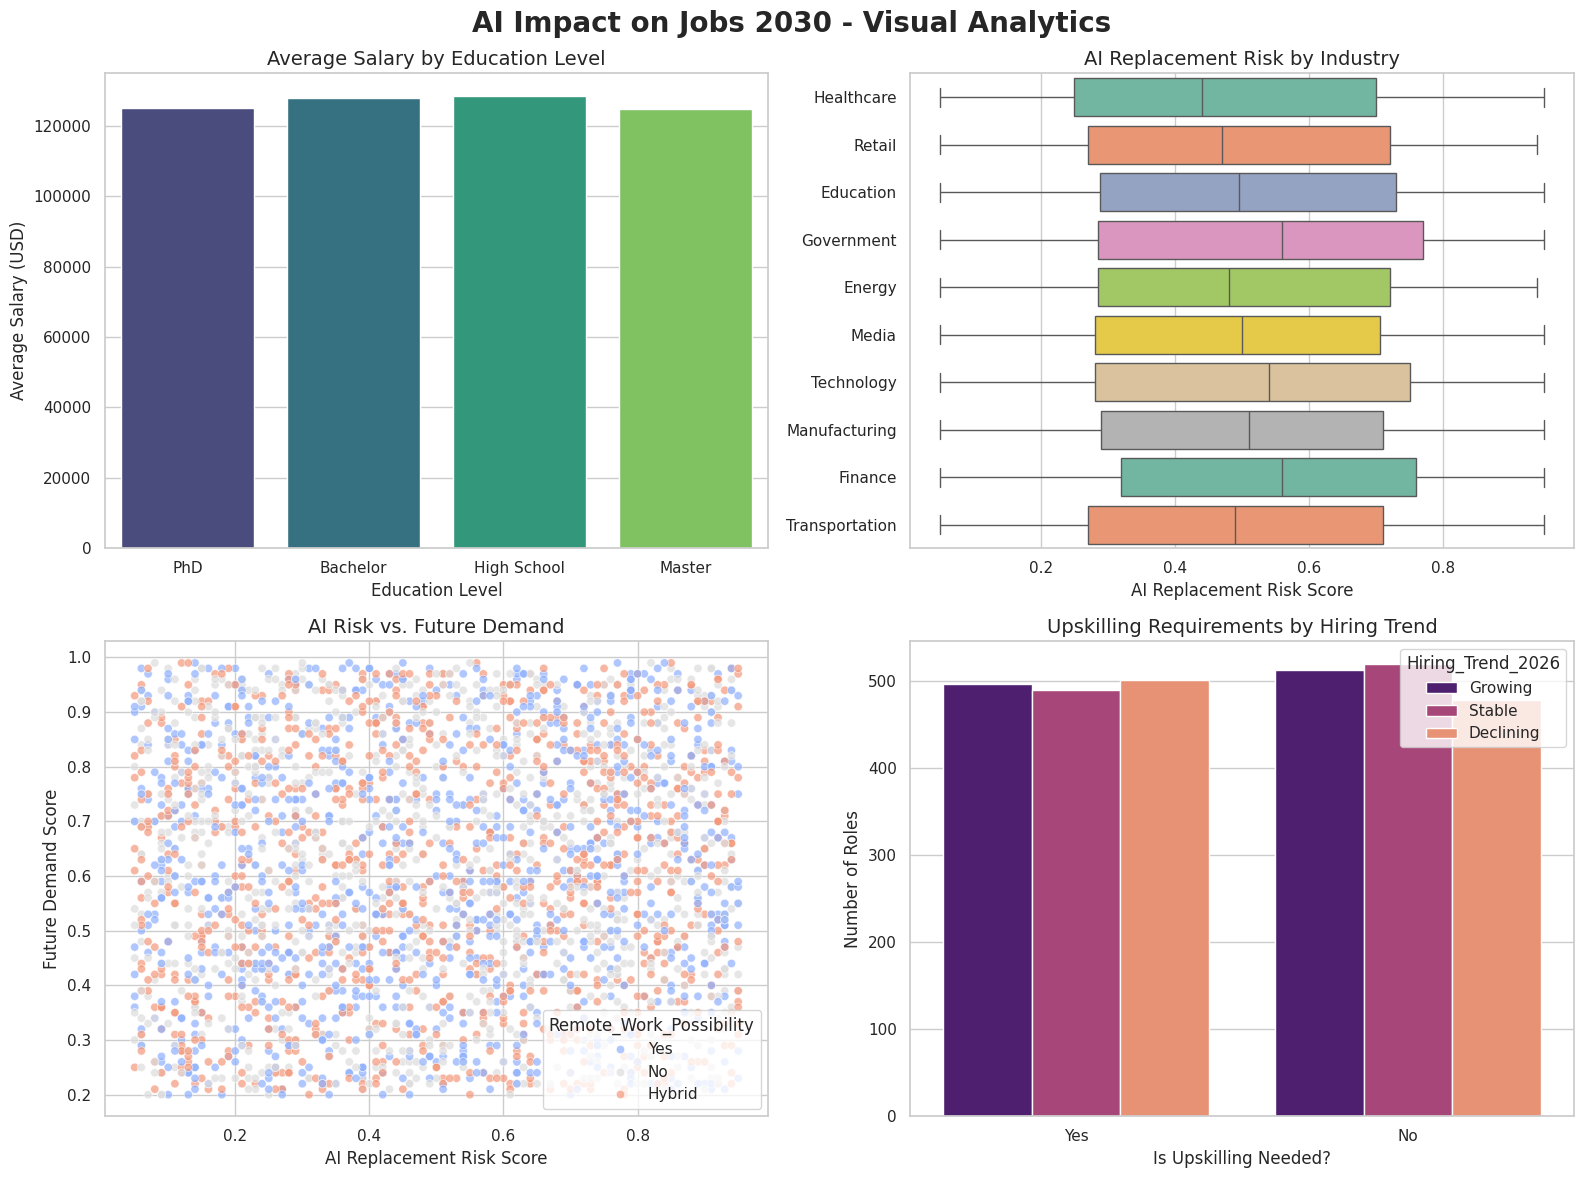

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('AI_Impact_on_Jobs_2030.csv')

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a large figure to hold 4 different charts (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('AI Impact on Jobs 2030 - Visual Analytics', fontsize=20, fontweight='bold')

# Chart 1: Average Salary by Education Level
sns.barplot(ax=axes[0, 0], data=df, x='Education_Level', y='Average_Salary_USD', palette='viridis', errorbar=None)
axes[0, 0].set_title('Average Salary by Education Level', fontsize=14)
axes[0, 0].set_xlabel('Education Level')
axes[0, 0].set_ylabel('Average Salary (USD)')

# Chart 2: AI Replacement Risk Distribution by Industry
sns.boxplot(ax=axes[0, 1], data=df, x='AI_Replacement_Risk', y='Industry', palette='Set2')
axes[0, 1].set_title('AI Replacement Risk by Industry', fontsize=14)
axes[0, 1].set_xlabel('AI Replacement Risk Score')
axes[0, 1].set_ylabel('')

# Chart 3: AI Risk vs. Future Demand (Scatter)
sns.scatterplot(ax=axes[1, 0], data=df, x='AI_Replacement_Risk', y='Future_Demand_Score', hue='Remote_Work_Possibility', palette='coolwarm', alpha=0.7)
axes[1, 0].set_title('AI Risk vs. Future Demand', fontsize=14)
axes[1, 0].set_xlabel('AI Replacement Risk Score')
axes[1, 0].set_ylabel('Future Demand Score')

# Chart 4: Upskilling Needs vs Hiring Trend
sns.countplot(ax=axes[1, 1], data=df, x='Upskilling_Needed', hue='Hiring_Trend_2026', palette='magma')
axes[1, 1].set_title('Upskilling Requirements by Hiring Trend', fontsize=14)
axes[1, 1].set_xlabel('Is Upskilling Needed?')
axes[1, 1].set_ylabel('Number of Roles')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [95]:
%%writefile show_schema.hql
USE ai_jobs_db;

SELECT '--- LIST OF TABLES IN DATABASE ---';
SHOW TABLES;

SELECT '--- STRUCTURE OF RAW TABLE ---';
DESCRIBE ai_jobs_raw;

SELECT '--- STRUCTURE OF PARTITIONED TABLE ---';
DESCRIBE ai_jobs_partitioned;

SELECT '--- LIST OF PARTITIONS CREATED ---';
SHOW PARTITIONS ai_jobs_partitioned;

Writing show_schema.hql


In [96]:
!hive -f show_schema.hql

Hive Session ID = 41f5fd1b-9a57-483f-b46a-9951f12138d1

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = b0c36498-cc59-489a-9ee5-f82b75a7c54e
OK
Time taken: 1.43 seconds
OK
--- LIST OF TABLES IN DATABASE ---
Time taken: 2.827 seconds, Fetched: 1 row(s)
OK
ai_jobs_partitioned
ai_jobs_raw
Time taken: 0.082 seconds, Fetched: 2 row(s)
OK
--- STRUCTURE OF RAW TABLE ---
Time taken: 0.168 seconds, Fetched: 1 row(s)
OK
employee_id         	string              	from deserializer   
job_title           	string              	from deserializer   
industry            	string              	from deserializer   
country             	string              	from deserializer   
education_level     	string              	from deserializer   
years_experience    	string              	from deserializer   
ai_replacement_risk 	string              	from deserializer   
future_demand_score 	string              	fro

In [97]:
%%writefile show_data.hql
USE ai_jobs_db;

SELECT '--- SAMPLE DATA FROM PARTITIONED TABLE ---';
SELECT Employee_ID, Job_Title, Industry, Average_Salary_USD
FROM ai_jobs_partitioned
LIMIT 10;

Writing show_data.hql


In [98]:
!hive -f show_data.hql

Hive Session ID = 8423fe48-deb8-4368-af97-d625b6e8f01c

Logging initialized using configuration in jar:file:/usr/local/hive/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
Hive Session ID = d1526771-acfc-49da-8a40-4a0f7ca9e2a7
OK
Time taken: 1.297 seconds
OK
--- SAMPLE DATA FROM PARTITIONED TABLE ---
Time taken: 2.855 seconds, Fetched: 1 row(s)
OK
AIJ-100002	HR Specialist	Education	124800
AIJ-100004	Healthcare Analyst	Education	178682
AIJ-100009	Product Manager	Education	48574
AIJ-100011	Cybersecurity Analyst	Education	33868
AIJ-100018	Digital Marketer	Education	153388
AIJ-100033	Machine Learning Engineer	Education	170473
AIJ-100036	Business Analyst	Education	56013
AIJ-100037	HR Specialist	Education	193855
AIJ-100043	Business Analyst	Education	114352
AIJ-100053	Cybersecurity Analyst	Education	149201
Time taken: 1.122 seconds, Fetched: 10 row(s)


In [99]:
import pandas as pd

# Load the exported analysis file (or the original CSV)
df = pd.read_csv('ai_industry_analysis.csv')

print("Hive Aggregation Results (Industry Analysis):")
# The 'display()' function creates a clean, formatted table in Colab
display(df.head(10))

Hive Aggregation Results (Industry Analysis):


,Industry,Job_Title,Avg_AI_Replacement_Risk,Avg_Average_Salary_USD,Avg_Future_Demand_Score
0,Education,AI Engineer,0.502500,89336.750000,0.653750
1,Education,Blockchain Developer,0.434118,121348.000000,0.566471
2,Education,Business Analyst,0.371429,120101.285714,0.678571
3,Education,Cloud Architect,0.712308,122993.846154,0.623077
4,Education,Cybersecurity Analyst,0.492941,110789.882353,0.621176
5,Education,Data Engineer,0.320909,124331.545455,0.585455
6,Education,Data Scientist,0.507647,131699.294118,0.629412
7,Education,DevOps Engineer,0.569286,147047.500000,0.555714
8,Education,Digital Marketer,0.463750,112559.562500,0.578750
9,Education,Financial Analyst,0.456667,113323.000000,0.613333
